# Topic modeling

Topic analysis is an NLP technique that analyses a corpus of text by automatically highlighting the most frequently occurring topics. It is an unsupervised learning technique because the number and description of topics are not known in advance. Like other unsupervised learning techniques, topic analysis requires human analysis to assess the quality of the extracted topics and interpret them. Topic analysis is therefore the first step in a more precise and targeted analysis of a corpus of documents. In this practical exercise, we will test several topic analysis techniques on a corpus of articles from the newspaper Le Monde.

In order to perform a more accurate analysis, select a type of article from the database among :
* 'ART': 'arts'
* 'ENT': 'entreprises'
* 'FRA': 'France'
* 'SOC': 'société'
* 'INT': 'International'
* 'SPO': 'sports'



In [15]:
%pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 86.3 MB/s  0:00:00m0:00:01
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load the corpus
df = pd.read_csv('data/LeMonde2003_9classes.csv.gz')
df = df[df['category'] == 'FRA'].sample(n=1000).reset_index(drop=True)
# select a type of articles to focus the analysis
print (f"Number of articles in the corpus : {df.shape}")
df.head()


Number of articles in the corpus : (1000, 2)


,text,category
0,le ministre de l'économie et des finances reco...,FRA
1,du triomphe aux regrets un mois seulement aura...,FRA
2,les centaines d'invités que devaient réunir sa...,FRA
3,nul n'est censé ignorer la loi encore faut-il ...,FRA
4,le gouvernement se veut déterminé les syndicat...,FRA


## Latent Dirichlet Allocation

[Latent Dirichlet Allocation (LDA)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html) is a probabilistic model in which each document is represented as a mixture of topics, and each topic is represented as a distribution over words. For each word in a document, a topic is sampled from the document’s topic distribution, and the word is then sampled from the corresponding topic’s word distribution. The model assumes a bag-of-words representation, meaning that it does not take word order into account and relies only on word frequencies, which can be obtained using vectorization methods such as CountVectorizer. 

The training phase consists of estimating the latent topic distributions and the document–topic proportions from the observed words, typically using approximate Bayesian inference methods such as variational inference or Gibbs sampling.

**Question**:

> * Encode the text of the selected articles using [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html).
> * train a LDA model on the encoded text.
> * Print the 10 most representative words for each topic.
> * In a new cell, add the STOPWORDS list as a parameter of CountVectorizer, retrain the model and print the 10 most representative words for each topic. Observe the changes.
> * In a new cell, lemmatize using the text spacy `fr_core_news_sm` model and train a LDA model on the lemmatized text. Print the 10 most representative words for each topic.  Observe the changes.


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import  LatentDirichletAllocation 
import matplotlib.pyplot as plt
import spacy

#! python -m spacy download fr_core_news_sm

def plot_top_words(model, vectorizer, n_top_words, title, nb_lines=2):
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(nb_lines, 5, figsize=(30, 30), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

n_features = 1000
n_topics = 10
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]
nlp = spacy.load("fr_core_news_sm", disable=["parser", "ner"])
df['lemmatized_text'] = [" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(df['text'])]

In [17]:
df

,text,category,lemmatized_text
0,le ministre de l'économie et des finances reco...,FRA,le ministre de le économie et de finance recon...
1,du triomphe aux regrets un mois seulement aura...,FRA,de triomphe à regret un mois seulement avoir p...
2,les centaines d'invités que devaient réunir sa...,FRA,le centaine de invité que devoir réunir samedi...
3,nul n'est censé ignorer la loi encore faut-il ...,FRA,nul ne être censé ignorer le loi encore falloi...
4,le gouvernement se veut déterminé les syndicat...,FRA,le gouvernement se vouloir déterminé le syndic...
...,...,...,...
995,l'amiral philippe de gaulle 81 ans fils du gén...,FRA,le amiral philippe de gaulle 81 an fil de géné...
996,l'interpellation a surgi du fond de la salle s...,FRA,le interpellation avoir surgir de fond de le s...
997,la bataille annoncée n'a pas eu lieu mais la p...,FRA,le bataille annoncer ne avoir pas avoir lieu m...
998,l'entourage d'emile zuccarelli le maire prg de...,FRA,le entourage de emile zuccarelli le maire prg ...


In [30]:
tf_vectorizer = CountVectorizer(
    min_df=10,
    max_df=0.7,
    ngram_range=(1, 2)
)

X = tf_vectorizer.fit_transform(df["lemmatized_text"])

In [21]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 310271 stored elements and shape (1000, 8475)>
  Coords	Values
  (0, 5181)	3
  (0, 8184)	1
  (0, 3251)	3
  (0, 6587)	1
  (0, 6085)	3
  (0, 3279)	1
  (0, 3338)	4
  (0, 6971)	2
  (0, 2500)	1
  (0, 83)	1
  (0, 6711)	3
  (0, 1668)	1
  (0, 5634)	7
  (0, 3071)	5
  (0, 7353)	4
  (0, 1673)	5
  (0, 7156)	1
  (0, 3942)	1
  (0, 53)	1
  (0, 2925)	1
  (0, 6355)	2
  (0, 3896)	2
  (0, 27)	1
  (0, 3939)	2
  (0, 6514)	2
  :	:
  (999, 673)	1
  (999, 894)	1
  (999, 6235)	1
  (999, 2145)	1
  (999, 7534)	1
  (999, 7398)	1
  (999, 2249)	1
  (999, 5791)	1
  (999, 4522)	1
  (999, 2011)	1
  (999, 6738)	1
  (999, 2444)	1
  (999, 6384)	1
  (999, 956)	1
  (999, 5718)	1
  (999, 2095)	1
  (999, 4423)	1
  (999, 2574)	1
  (999, 841)	1
  (999, 7158)	1
  (999, 6678)	1
  (999, 4696)	1
  (999, 3241)	1
  (999, 8367)	1
  (999, 4430)	1


In [26]:
# Encode the text with CountVectorizer
# YOUR CODE HERE

# Crée le modèle LDA
lda = LatentDirichletAllocation(
    n_components=10,    # nombre de topics
    random_state=42,
    learning_method='batch'  # 'batch' pour un dataset modéré
)

# Entraîne le modèle sur la matrice document-terme
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


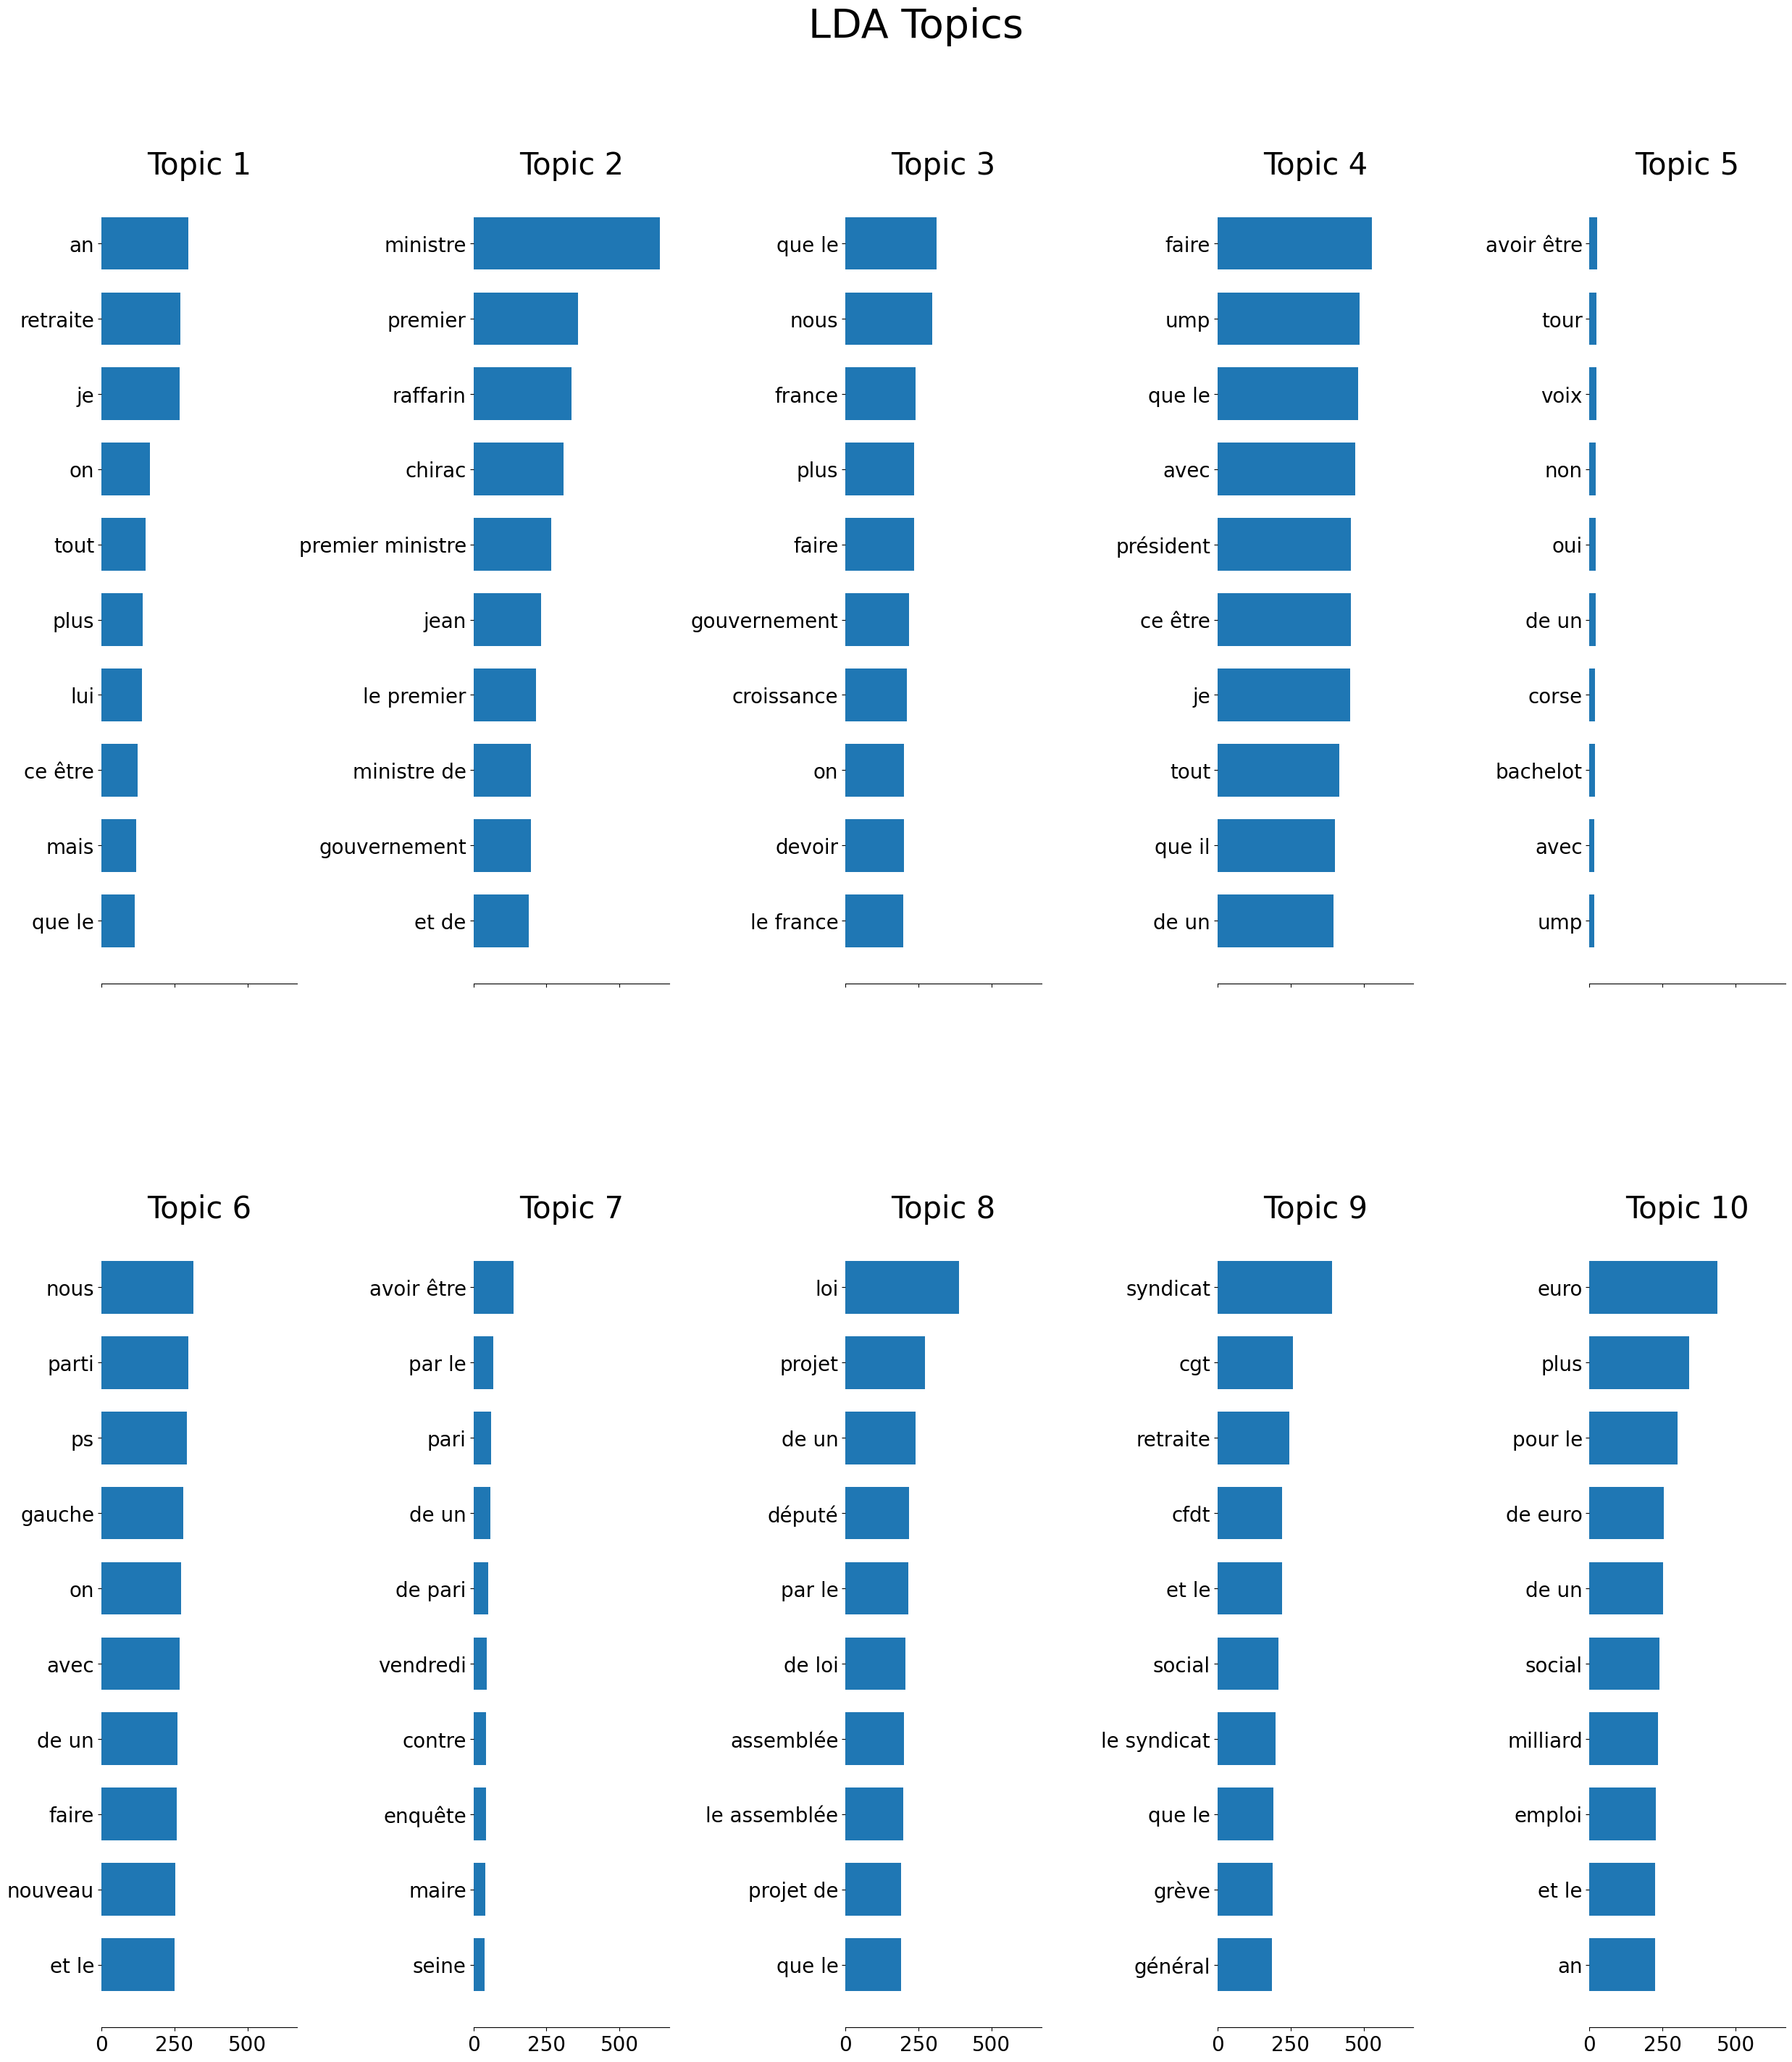

In [31]:
plot_top_words(lda, tf_vectorizer, n_top_words=10, title="LDA Topics")

### PyLDAvis
Once an LDA model has been trained, [pyLDAvis](https://github.com/bmabey/pyLDAvis) can be used to visualise and explore the discovered topics interactively. This tool provides a two-dimensional representation of the topics, in which the distance between circles reflects their similarity and the size of each circle corresponds to how prevalent the topic is in the corpus. It also displays the most relevant words for each topic and allows users to adjust a relevance parameter to balance frequency and distinctiveness. This interactive visualisation enables more effective interpretation, evaluation and comparison of topics than simply inspecting lists of keywords.

In [32]:
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

pyLDAvis.lda_model.prepare(lda, X, tf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.011240 -0.099526       1        1  24.976134
5     -0.007826 -0.120393       2        1  14.762721
9      0.060010  0.176718       3        1  13.029802
8      0.064756 -0.024557       4        1  10.496112
2      0.094942  0.012718       5        1   9.558563
7      0.004478  0.066458       6        1   9.407902
1     -0.000786 -0.003673       7        1   9.326246
0      0.142500 -0.017126       8        1   5.385721
6     -0.218398  0.099355       9        1   2.130490
4     -0.128436 -0.089974      10        1   0.926310, topic_info=            Term         Freq        Total Category  logprob  loglift
947   avoir être   804.000000   804.000000  Default  30.0000  30.0000
5181    ministre  1313.000000  1313.000000  Default  29.0000  29.0000
3867          je   955.000000   955.000000  Default  28.0000  28.0000
6744    retraite   698.000000   698.000000  Default  27.0000  27.0000
424           an   789.000000   789.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
462     annoncer    10.006646   241.623012  Topic10  -5.9495   1.4976
2657      député     9.751266   433.516802  Topic10  -5.9753   0.8872
6469   qui avoir     9.580375   484.207969  Topic10  -5.9930   0.7589
2347        deux     9.627907   630.605444  Topic10  -5.9881   0.4997
6431      que le     9.825008  1832.020721  Topic10  -5.9678  -0.5465

[763 rows x 6 columns], token_table=      Topic      Freq             Term
term                                  
0         2  0.088120              000
0         3  0.582127              000
0         4  0.218965              000
0         5  0.005341              000
0         6  0.034714              000
...     ...       ...              ...
8412     10  0.005563         être pas
8425      3  0.086752  être poursuivre
8425      7  0.173504  être poursuivre
8425      8  0.086752  être poursuivre
8425      9  0.520512  être poursuivre

[2683 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 6, 10, 9, 3, 8, 2, 1, 7, 5])

## Non-negative matrix factorisation

[Non-negative matrix factorisation (NMF)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html) is a linear algebra-based topic modelling method that decomposes a document-term matrix into two lower-dimensional non-negative matrices, `H` and `W`. The matrix `W` represents the importance of each topic in each document, while the matrix `H` (components_) represents the importance of each word in each topic. Unlike LDA, NMF is an optimisation-based approach that factorises the input matrix by minimising a reconstruction error under non-negativity constraints, rather than a probabilistic generative model. When applied to text data, which is typically represented using [TF-IDF](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) features, NMF produces interpretable topics characterised by sets of highly weighted words. 

**Question**:

> * Encode the text of the selected articles using `TfidfVectorizer`.
> * [train a NMF model](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html#sklearn.decomposition.NMF.fit_transform) on the encoded text.
> * Print the 20 most representative words for each topic.
> * In a new cell, add the STOPWORDS list as a parameter of CountVectorizer, retrain the model and print the 20 most representative words for each topic. Observe the changes.
> * In a new cell, lemmatize using the text spacy `fr_core_news_sm` model and train a LDA model on the lemmatized text. Print the 20 most representative words for each topic.  Observe the changes.
> * Analyse each topic and describe it with label. Create of dictionnary to map each topic to its label

In [38]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import spacy
import pandas as pd

# --- Paramètres ---
n_topics = 10
n_top_words = 20

# --- Optionnel : Stopwords français ---
STOPWORDS = [x.strip() for x in open('data/stop_word_fr.txt').readlines()]

# --- 1️⃣ Encode the text using TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words=None,       # mettre STOPWORDS pour exclure mots vides
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7
)
tfidf = tfidf_vectorizer.fit_transform(df['text'])  # df['text'] = tes articles

# --- 2️⃣ Define the NMF model ---
nmf = NMF(n_components=n_topics, random_state=42)

# --- 3️⃣ Train the NMF ---
nmf.fit(tfidf)

# --- 4️⃣ Print the 20 most representative words for each topic ---
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):
    top_indices = np.argsort(-topic)[:n_top_words]  # trier par poids décroissant
    top_words = [feature_names[i] for i in top_indices]
    
    print(f"Topic {topic_idx}:")
    print("  " + ", ".join(top_words))
    print()

# --- 5️⃣ Map topics to labels (exemple) ---
topic_label = {
    0: 'Générique / mots fonctionnels',
    1: 'Économie / finances',
    2: 'Politique / élections',
    3: 'Actualité / société',
    4: 'Syndicats / grèves',
    5: 'Politique / parti socialiste',
    6: 'Politique / extrême droite',
    7: 'Politique / gouvernement',
    8: 'Législation / lois',
    9: 'Retraites / emploi / social'
}

Topic 0:
  nous, on, ne, je, vous, qu, ce, plus, elle, mais, se, comme, sont, faut, ils, fait, ou, si, cela, il faut

Topic 1:
  euros, milliards, 2003, milliards euros, croissance, millions, 2004, 000, déficit, budget, dépenses, année, 2002, baisse, plus, france, pib, finances, la france, millions euros

Topic 2:
  ump, udf, de ump, bayrou, président, liste, de udf, président de, régionales, député, élections, maire, juppé, région, tour, le président, élections régionales, parti, alpes, conseil

Topic 3:
  été, ont, ont été, avait, paris, personnes, mis en, vendredi, ans, mis, de paris, examen, août, deux, février, corse, avoir, décembre, enquête, maire

Topic 4:
  cgt, grève, cfdt, syndicats, la cgt, la cfdt, éducation, fo, les syndicats, mai, unsa, retraites, fsu, de grève, juin, éducation nationale, 000, mobilisation, secrétaire général, de éducation

Topic 5:
  ps, hollande, gauche, du ps, parti, verts, secrétaire, premier secrétaire, congrès, la gauche, nouveau, le ps, nps, socia

### Document/Topic analysis
For each document, the W matrix gives us the weight of each topic in that document. It is therefore possible to normalise these weights and graphically represent the relative importance of each topic.

**Question**:

> * Normalise the W matrix by dividing it by its sum per row ([np.sum(axis=1)](https://numpy.org/doc/2.3/reference/generated/numpy.sum.html))
> * Extract the index of the column with the highest value ([argmax](https://numpy.org/devdocs/reference/generated/numpy.argmax.html)) and the value (max) and add this data to the dataframe


The following cell displays examples of article text with the dominant theme, its label and its score.

In [37]:
dominant_topic_idx

array([1, 6, 7, 0, 4, 7, 0, 2, 0, 4, 5, 1, 1, 0, 5, 1, 9, 0, 4, 7, 3, 9,
       8, 8, 5, 5, 2, 5, 1, 8, 7, 5, 7, 8, 5, 3, 1, 9, 2, 9, 3, 3, 9, 0,
       9, 4, 1, 3, 9, 7, 2, 2, 2, 4, 1, 8, 2, 6, 8, 6, 8, 8, 2, 5, 1, 2,
       8, 6, 0, 3, 7, 1, 7, 1, 4, 3, 6, 3, 6, 5, 7, 3, 4, 4, 5, 4, 1, 1,
       9, 4, 5, 2, 0, 7, 9, 7, 8, 3, 9, 1, 0, 0, 9, 1, 8, 9, 9, 0, 9, 1,
       2, 1, 9, 3, 7, 2, 0, 2, 1, 2, 2, 3, 0, 7, 1, 1, 7, 3, 2, 8, 0, 7,
       7, 8, 6, 3, 2, 0, 1, 7, 2, 3, 2, 1, 8, 4, 7, 1, 9, 5, 7, 4, 9, 2,
       9, 7, 4, 0, 6, 5, 3, 5, 7, 2, 3, 2, 1, 8, 2, 6, 8, 4, 5, 3, 2, 7,
       4, 1, 3, 4, 8, 1, 9, 2, 4, 0, 0, 9, 1, 3, 7, 8, 2, 3, 9, 0, 8, 8,
       6, 2, 0, 4, 6, 7, 8, 7, 9, 8, 9, 3, 8, 1, 3, 5, 5, 2, 1, 3, 1, 5,
       3, 7, 8, 0, 9, 4, 3, 2, 7, 5, 3, 5, 5, 8, 1, 1, 7, 7, 3, 3, 5, 3,
       3, 0, 5, 4, 3, 5, 5, 5, 2, 1, 0, 1, 0, 2, 5, 1, 7, 8, 7, 7, 9, 6,
       8, 3, 5, 8, 1, 3, 6, 1, 8, 7, 3, 4, 3, 2, 8, 2, 3, 4, 4, 8, 7, 7,
       0, 3, 4, 3, 7, 0, 1, 2, 7, 3, 7, 1, 5, 8, 2,

In [39]:
import numpy as np

# Normalize the W matrix
# Extraire la matrice W
W = nmf.transform(tfidf)  # shape = (n_documents, n_topics)

# Normaliser par ligne pour obtenir des poids relatifs
W_norm = W / W.sum(axis=1, keepdims=True)

# Index du topic dominant pour chaque document
dominant_topic_idx = np.argmax(W_norm, axis=1)

# Valeur du topic dominant (poids normalisé)
dominant_topic_score = W_norm.max(axis=1)

# Ajouter ces colonnes au DataFrame
df['dominant_topic'] = dominant_topic_idx
df['topic_score'] = dominant_topic_score

In [40]:
# Afficher les 5 premiers documents avec leur topic dominant et score
for i, row in df.head(5).iterrows():
    topic = row['dominant_topic']
    score = row['topic_score']
    label = topic_label.get(topic, "Unknown")
    print(f"Document {i}:")
    print(f"  Dominant Topic {topic} ({label}) - Score: {score:.3f}")
    print(f"  Text: {row['text'][:200]}...\n")

Document 0:
  Dominant Topic 1 (Économie / finances) - Score: 0.471
  Text: le ministre de l'économie et des finances reconnaît pour la première fois que la france sera sans doute incapable en 2004 de respecter les critères du pacte européen de stabilité et de croissance sign...

Document 1:
  Dominant Topic 6 (Politique / extrême droite) - Score: 0.548
  Text: du triomphe aux regrets un mois seulement aura passé mardi matin 8 avril à l'heure où jean-pierre raffarin s'employait à tempérer les ardeurs vengeresses des députés de l'ump jean-claude gaudin a sonn...

Document 2:
  Dominant Topic 7 (Politique / gouvernement) - Score: 0.338
  Text: les centaines d'invités que devaient réunir samedi 22 février quatre maires de droite en accueillant dans leur commune jean-pierre raffarin n'ont pas fait illusion ce ne sont pas ces bains de foule qu...

Document 3:
  Dominant Topic 0 (Générique / mots fonctionnels) - Score: 0.342
  Text: nul n'est censé ignorer la loi encore faut-il pouvoir en co

The following cell displays examples of article text with the dominant theme, its label and its score.

**Question**:

> * Analyse the coherence between the text, the dominant topic and the topic distribution.


Document 246
Dominant topic: 3 - Actualité / société (0.966)

quatre personnes âgées sont décédées à l'hôpital de saint-valery-en-caux seine-maritime entre samedi
20 et mardi 23 décembre vraisemblablement en raison d'une infection broncho-pulmonaire contractée
dans cet établissement





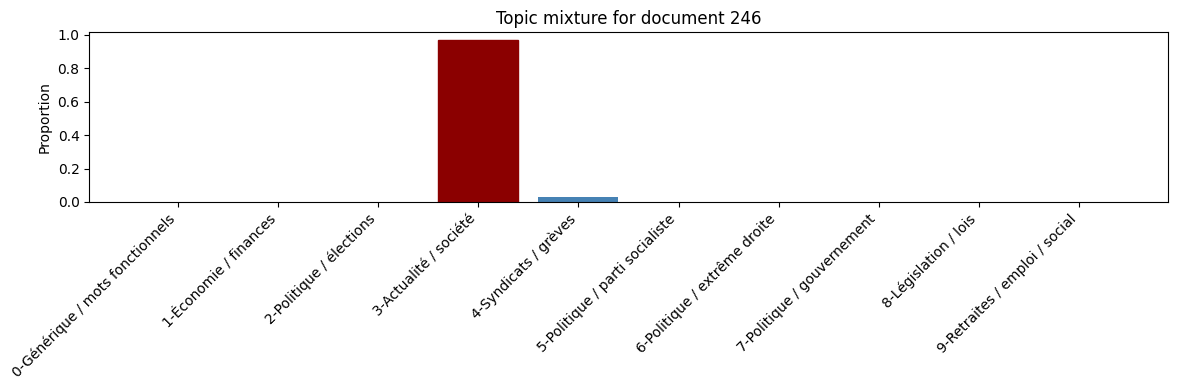


Document 132
Dominant topic: 7 - Politique / gouvernement (0.680)

les traits tirés visiblement marqué par une période de difficultés économiques et de dégradation de
sa cote de popularité jean-pierre raffarin n'en finit plus de découvrir les charmes de sa fonction
accueilli à avignon vendredi 7 mars par quelque 350 personnes qui scandaient raffarin ta politique
ne vaut rien le premier ministre s'est rendu au palais des papes pour y présider en compagnie
notamment de son homologue hongrois peter medgyessy et du ministre des affaires sociales françois
fillon un forum europe intitulé l'europe un projet social inaugurés à orléans le 6 décembre 2002 ces
forums thématiques trois autres devraient se tenir d'ici l'automne sont destinés à mobiliser
l'opinion dans la perspective d'un référendum sur les futures institutions européennes le monde du 9
décembre 2002 l'actualité de la crise irakienne a éclipsé cet objectif initial alors que l'image de
jacques chirac à la différence de celle de son 

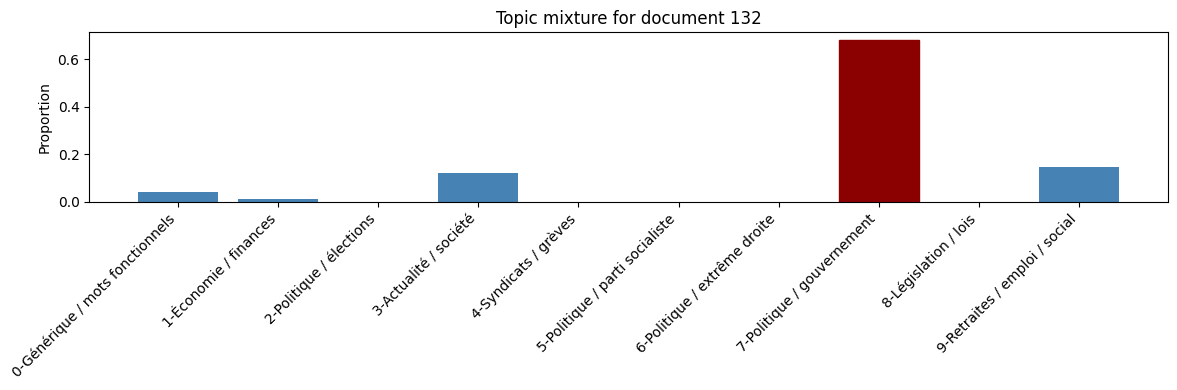


Document 597
Dominant topic: 2 - Politique / élections (0.593)

les partisans d'alain carignon ont remporté les neuf postes de délégué de circonscription dans
l'isère lors des élections internes organisées vendredi 4 avril dans ce département l'ancien maire
rpr de grenoble 1983-1995 condamné en 1996 pour corruption et qui a purgé 29 mois de prison a
annoncé sa candidature lundi 7 avril à la présidence de l'ump iséroise





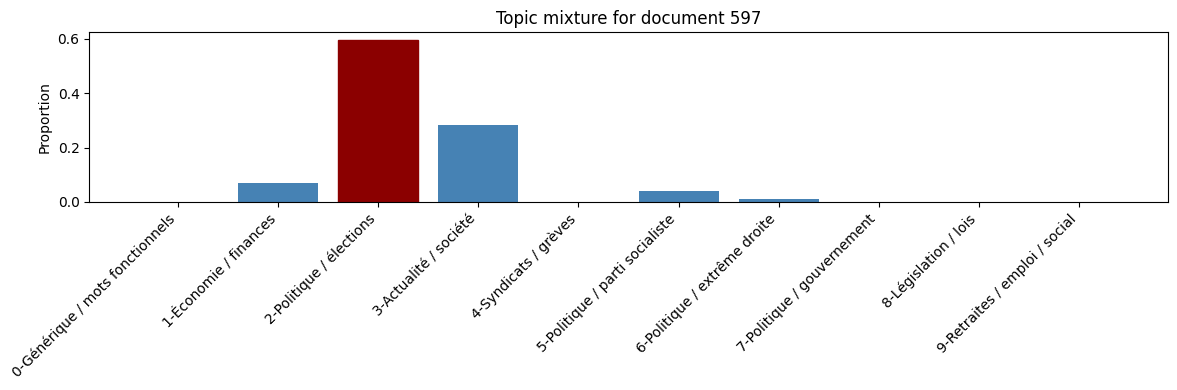


Document 134
Dominant topic: 6 - Politique / extrême droite (0.868)

interrogé sur les rivalités au sein de son parti jean-marie le pen a déclaré dans un entretien
publié vendredi 17 octobre par le télégramme de brest qu ' il n'y a pas de société humaine où il n'y
a pas d'agacements m le pen a ajouté que le délégué général du mouvement bruno gollnisch était un
homme de grande moralité c'est pourquoi il occupe la responsabilité principale après moi





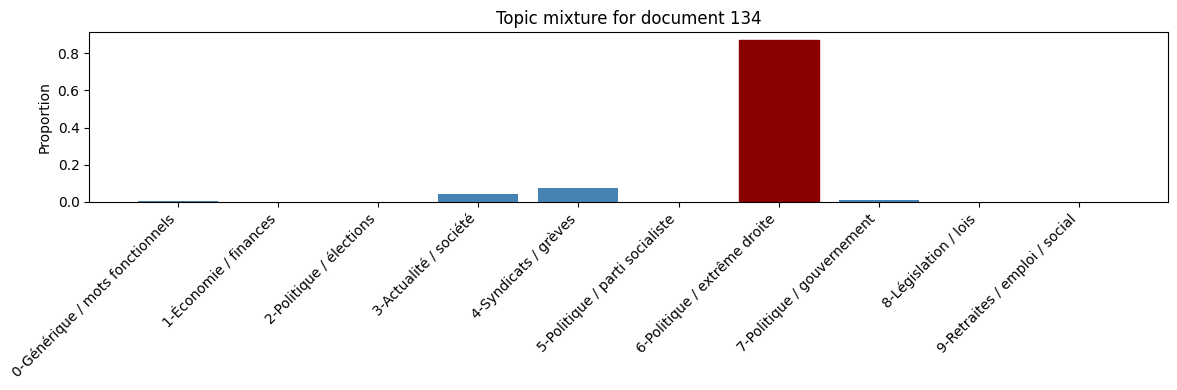


Document 237
Dominant topic: 7 - Politique / gouvernement (0.526)

une méchante rumeur court depuis des mois le véritable ministre de l'économie ne s'appelle pas
francis mer mais jean-françois cirelli il ne travaille pas à bercy mais à matignon dans l'ombre de
jean-pierre raffarin il n'a pas été choisi par le premier ministre mais dépêché par le chef de
l'etat qui a demandé à son ancien conseiller économique de faire profiter le premier ministre d'un
savoir-faire politique forgé durant la cohabitation m. raffarin a vite évalué le pedigree
intellectuel et moral du directeur adjoint de son cabinet qu'il n'avait que croisé durant la
campagne présidentielle il est à la fois vif argent et loyal de coeur dit-il avant d'ajouter pour
ceux qui voient en lui le véritable patron de son équipe à matignon il a la solidité d'un très bon
numéro 2 certains dirigeants de la droite pourtant le consacrent déjà vice-ministre de l'économie a
44 ans m. cirelli remplit une partie du vide laissé par m mer qu

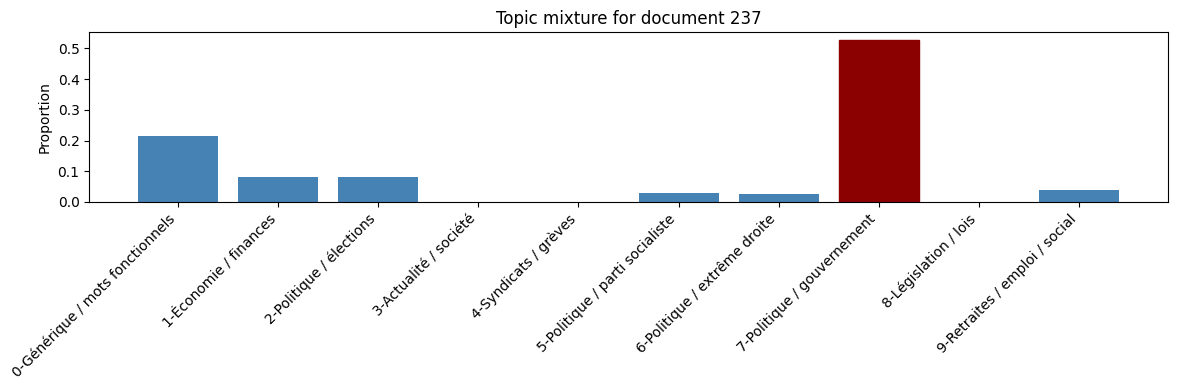

In [43]:
import matplotlib.pyplot as plt
import textwrap
import numpy as np

# Assure-toi que la matrice normalisée W existe
W_normalized = W / W.sum(axis=1, keepdims=True)

# Crée les noms pour les axes x : "0-Économie / finances", etc.
topic_names = [f"{k}-{topic_label[k]}" for k in topic_label.keys()]

# Affiche 5 documents aléatoires
for row in df.sample(n=5, random_state=2026).itertuples():
    
    doc_id = row.Index
    topic_distribution = W_normalized[doc_id]  # ligne correspondante dans W normalisée
    dominant_topic = row.dominant_topic
    dominant_score = row.topic_score
    dominant_label = topic_label[dominant_topic]
    
    # Affichage texte
    print(f"\nDocument {doc_id}")
    print(f"Dominant topic: {dominant_topic} - {dominant_label} ({dominant_score:.3f})\n")
    text = textwrap.fill(row.text, width=100)
    print(text[:3000])  # afficher max 1200 caractères pour ne pas saturer le notebook
    print("\n\n")
    
    # Graphique de distribution des topics
    plt.figure(figsize=(12,4))
    bars = plt.bar(topic_names, topic_distribution, color="steelblue")
    bars[dominant_topic].set_color("darkred")  # topic dominant en rouge
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Proportion")
    plt.title(f"Topic mixture for document {doc_id}")
    plt.tight_layout()
    plt.show()

## Topic modeling with embeddings : Bertopic

Unlike LDA and NMF, which rely on word frequency, [BERTopic](https://maartengr.github.io/BERTopic/index.html) is a topic modelling approach based on contextual embeddings to identify semantic similarities between documents. BERTopic combines transformer-based sentence embeddings, dimensionality reduction and density-based clustering to discover topics that reflect the semantic structures beyond simple word co-occurrence patterns. In this section, we will explore how BERTopic works and compare its results with those of previously implemented models.

**Question**:

> * Use [SentenceTransformer](https://sbert.net/#sentencetransformers-documentation) to encode the text of the articles using a model adapted to French from [HuggingFace](https://huggingface.co/models?library=sentence-transformers)
> * Create a CountVectorizer using the French stopwords to identify the topic labels
> * Create a BERTopic object with the CountVectorizer as parameter and fit it on the documents
> * Explore the topics with `topic_model.get_topic_info()` and compare them with the topics discovered by NMF.

In [44]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer

# --- 1️⃣ Préparer les documents ---
docs = df['text'].tolist()  # liste de textes

# --- 2️⃣ Encoder les documents avec un modèle adapté au français ---
# Exemple : 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
# qui fonctionne bien pour le français
sentence_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

embeddings = sentence_model.encode(docs, show_progress_bar=True)

# --- 3️⃣ Créer un CountVectorizer avec les stopwords français ---
vectorizer = CountVectorizer(stop_words=STOPWORDS)

# --- 4️⃣ Créer et entraîner le modèle BERTopic ---
topic_model = BERTopic(
    vectorizer_model=vectorizer,
    language="french",
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs, embeddings)

# --- 5️⃣ Explorer les topics ---
topic_info = topic_model.get_topic_info()
print(topic_info.head(10))  # Affiche les 10 premiers topics

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-06 14:42:41.145998: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 14:42:41.853267: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 14:42:51.174634: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different 

   Topic  Count                                     Name  \
0     -1    427  -1_gouvernement_ministre_jean_président   
1      0     66                   0_examen_juge_mis_bové   
2      1     49                 1_loi_texte_projet_sénat   
3      2     46             2_gauche_hollande_congrès_ps   
4      3     46                       3_ump_pen_liste_fn   
5      4     35                  4_cgt_cfdt_syndicats_fo   
6      5     30        5_éducation_ferry_enseignants_000   
7      6     27               6_milliards_euros_tva_2004   
8      7     26       7_millon_directeur_ministre_ancien   
9      8     25       8_hôpitaux_assurance_euros_maladie   

                                      Representation  \
0  [gouvernement, ministre, jean, président, fran...   
1  [examen, juge, mis, bové, yvan, paris, enquête...   
2  [loi, texte, projet, sénat, sénateurs, députés...   
3  [gauche, hollande, congrès, ps, parti, militan...   
4  [ump, pen, liste, fn, maire, udf, jean, voix, ...   
5  

In [ ]:
topic_model.get_topic_info()

In [ ]:
topic_model.visualize_documents(
    docs=docs,
    embeddings=embeddings,
    hide_annotations=True,
    topics=[0, 1, 2, 3, 4, 5,6, 7, 8, 9],
    height=600,
    width=1000
)

## Extra : Topic number analysis

In topic modelling, selecting an appropriate number of topics is crucial because it directly affects the interpretability, granularity and coherence of the discovered themes. Too few topics may merge distinct concepts, while too many may fragment the corpus into noisy or redundant subtopics.

Several metrics have been designed to evaluate the semantic quality of topics. The [most commonly used](https://radimrehurek.com/gensim/models/coherencemodel.html) are :
* u_mass, which measures word co-occurrence based on document frequencies within the corpus; 
* c_v, which combines sliding-window co-occurrence and normalised pointwise mutual information (NPMI) with a cosine similarity measure; 
* c_uci, which relies on pointwise mutual information (PMI) computed over word co-occurrences; 
* c_npmi, which is a normalised version of PMI that scales scores between −1 and 1 to improve interpretability.

The following cells visualise how the coherence of topics evolves as the number of topics (k) increases. For each coherence metric (u_mass, c_v, c_uci and c_npmi), we calculate the coherence score for various values of k. Since these metrics have different scales and are not directly comparable, we apply min–max normalisation independently to each metric. This enables us to compare their relative trends across different numbers of topics. The resulting plot helps to identify values of k that provide a good balance between topic granularity and semantic coherence.'



In [ ]:
from gensim.corpora import Dictionary

analyzer = tfidf_vectorizer.build_analyzer()

tokenized_texts = [
    analyzer(doc)
    for doc in df.lemmatized_text
]


dictionary = Dictionary(tokenized_texts)

# Optional but recommended:
dictionary.filter_extremes(no_below=5, no_above=0.95)


In [ ]:
from gensim.models.coherencemodel import CoherenceModel

def get_topics(model, feature_names, n_top_words):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        # Get indices of top words (descending order)
        top_indices = np.argsort(-topic)[:n_top_words]
        # Map indices to words
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)
    return topics

feature_names = tfidf_vectorizer.get_feature_names_out()

# for each number of topics, we will compute the 4 metrics
topic_range = [5, 10, 15, 20, 30]
coherence_metrics = ['u_mass', 'c_v', 'c_uci', 'c_npmi']
for metrics in coherence_metrics:
    results[metrics] = {}


for k in topic_range:
    # fit the model with k topics
    nmf = NMF(
        n_components=k,
        random_state=42
    )

    W = nmf.fit_transform(tfidf)
    topics = get_topics(nmf, feature_names, 10)
    for met in coherence_metrics:

        coherence_model = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence=met
        )

        coherence_score = coherence_model.get_coherence()
        results[met][k] =  coherence_score
        print(f"NMF coherence for {k} topic and metrics {met}: {coherence_score}")

In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))

for met in coherence_metrics:
    ks = sorted(results[met].keys())
    scores = np.array([results[met][k] for k in ks])

    # Min-max normalize per metric
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min())

    plt.plot(ks, norm_scores, marker='o', label=met)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Coherence Score")
plt.title("Normalized Coherence Comparison")
plt.legend()
plt.grid(True)
plt.show()